# Lineage constraints do not establish accuracy

**A five-cell public example · CPU only · Authored synthetic input**

Tracking requires deciding which cell at one time point corresponds to each cell at the next. Divisions make independent parent selection inadequate: one parent can have two children, but should not acquire an arbitrary number. This notebook calls the repository’s actual SciPy MILP solver and separates a valid graph from a correct graph.

All cells and scores in `fixture.json` are invented. The authored truth is **A → C, A → D, B → E**. No model is trained or invoked. Nothing here reproduces the externally scored **0.947** result.

Run from the repository root or `examples/`. Install `requirements-test.txt` plus a Jupyter environment; then run the cells in order. Saved outputs are included for reading without installation. Published cells were executed in order through in-process IPython, then saved and reopened; remote Jupyter kernel execution is not claimed.

In [1]:
from pathlib import Path
import importlib.util
import pandas as pd
from IPython.display import SVG, display

candidates = [Path.cwd(), *Path.cwd().parents]
root = next(path for path in candidates if (path / "examples/run_demo.py").is_file())
spec = importlib.util.spec_from_file_location("lineage_demo", root / "examples/run_demo.py")
demo = importlib.util.module_from_spec(spec)
spec.loader.exec_module(demo)
result = demo.run_demo()
print(result["scope"])
print("Actual implementation:", result["solver"])

authored synthetic example; no inference or official evaluation
Actual implementation: biohub_tracking.public_graph_methods.solve_constrained_edges


## One fixture, three outcomes

The first pass chooses the best-scoring parent independently for each child, which gives A three children. The next pass maximizes total candidate score while enforcing at most two children per parent and one parent per child. A third pass uses deliberately misleading scores to expose the limitation: structural constraints still permit an incorrect lineage.

The displayed edge agreement uses known IDs and complete toy truth. It is **not the organizer’s metric**, which includes spatial matching, anisotropy, sparse labels, and division-event accounting.

In [2]:
labels = {node["node_id"]: node["label"] for node in result["nodes"]}
rows = []
for name, scenario in result["scenarios"].items():
    rows.append({
        "Scenario": name.replace("_", " "),
        "Selected links": ", ".join(f"{labels[source]} → {labels[target]}" for source, target in scenario["edges"]),
        "Valid topology": scenario["valid_topology"],
        "TP": scenario["true_positive"],
        "FP": scenario["false_positive"],
        "FN": scenario["false_negative"],
        "Toy edge agreement": scenario["toy_edge_jaccard"],
    })
display(pd.DataFrame(rows).set_index("Scenario"))
assert result["scenarios"]["constrained"]["edges"] == result["expected_edges"]
assert result["scenarios"]["valid_but_wrong"]["valid_topology"]
assert result["scenarios"]["valid_but_wrong"]["toy_edge_jaccard"] < 1.0

,Selected links,Valid topology,TP,FP,FN,Toy edge agreement
Scenario,,,,,,
independent,"A → C, A → D, A → E",False,2,1,1,0.5
constrained,"A → C, A → D, B → E",True,3,0,0,1.0
valid but wrong,"A → C, A → E, B → D",True,1,2,2,0.2


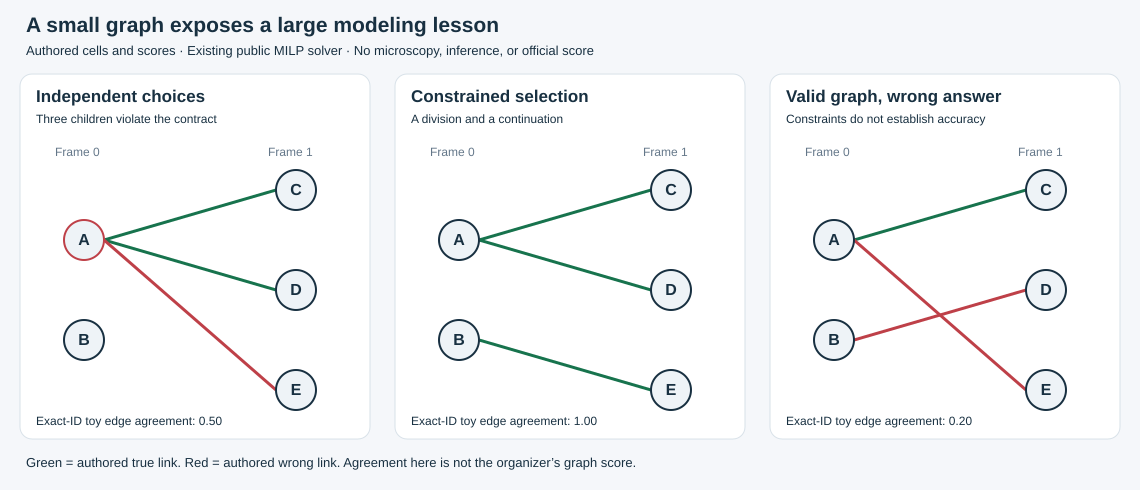

In [3]:
display(SVG(data=demo.render_svg(result)))

## What this establishes

The public solver produces the expected constrained solution on an authored fixture, and the example’s structural checker rejects malformed graphs. The deliberately wrong case demonstrates why passing those checks is insufficient evidence of scientific accuracy.

A real system must also preserve detections, match nodes in physical coordinates, handle incomplete annotation, score divisions, and test generalization on independent movies. See [the executed research notebooks](../notebooks/README.md) and [results](../RESULTS.md) for those separate evidence tiers. This example adds no new scientific or competition result.